# Experiments 14-30, All in One File

Every experiment from the last two rounds, combined into a single
notebook. Shared setup (loading poets, fetching the Quran, building
embeddings) runs once at the top; every experiment below reuses it.

- **14:** Control test — synthetic meaningless text vs. the 35 poets
- **15-17:** Hizb / hizb-pairs / surahs clustered among themselves, no poets
- **18:** AllPoets vs. Quran (whole) — direct similarity
- **19-21:** AllPoets vs. surahs / hizb / hizb-pairs
- **22:** Quran vs. individual poets, kept separate
- **23-24:** Quran (whole) vs. `35Vector` / `19Vector`
- **25-30:** surahs / hizb / hizb-pairs vs. `35Vector` / `19Vector`

`AllPoets` = all 260 poets averaged into one entity.
`35Vector` = the 35 well-documented poets averaged into one entity.
`19Vector` = the poets sharing the Quran's cluster in the original
all-260-poets run, averaged into one entity — re-derived fresh in this
notebook rather than hardcoded, so it's always correct.

**Before you start:** put `poems.db` in the same folder as this
notebook. Reuses your cached poet and ayah embeddings if this sits in
the same folder as earlier runs — most of this should run fast, with
one exception: if `ayah_embeddings.pkl` isn't cached yet, embedding all
6,236 ayat individually takes ~15-25 minutes the first time.

Run cells top to bottom, **Shift+Enter**.

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration
import re, sqlite3, hashlib, json, warnings, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

DB_PATH = Path("poems.db")
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
EMBED_CACHE_DIR = Path("embed_cache"); EMBED_CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_VERSES_PER_POEM = 20

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU.")

def split_verses(poem_text):
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

def normalize_word(w):
    w = re.sub(r"[\u0610-\u061A\u064B-\u065F\u06D6-\u06ED\u0670]", "", w)
    w = re.sub(r"\u0640", "", w)
    w = re.sub(r"[\u0622\u0623\u0625]", "\u0627", w)
    return w.strip()

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})
print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


In [3]:
# CELL 3 -- Load the 260 poets from poems.db
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
df = df.drop_duplicates(subset=["poem_hash"]).copy()

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

poet_total_verses = {
    poet: sum(len(split_verses(p)) for p in poems)
    for poet, poems in poems_by_poet.items()
}

print(f"Poets loaded: {len(poems_by_poet)}")

Poets loaded: 260


In [4]:
# CELL 4 -- Fetch Quran text WITH hizb-quarter metadata
cache_file = CACHE_DIR / "quran_ayat_with_hizb.json"

if cache_file.exists():
    print("Loading Quran (with hizb metadata) from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching Quran from Al Quran Cloud API...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    surahs_raw = resp.json()["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

surah_names = {}
surah_poem_text = {}
ayah_records = []
for s in surahs_raw:
    snum = s["number"]
    surah_names[snum] = s["englishName"]
    ayat_texts = [a["text"] for a in s["ayahs"]]
    surah_poem_text[snum] = "\n".join(ayat_texts)
    for a in s["ayahs"]:
        hizb_number = ((a["hizbQuarter"] - 1) // 4) + 1
        ayah_records.append({
            "surah_number": snum, "ayah_number": a["numberInSurah"],
            "text": a["text"], "hizb_number": hizb_number,
        })

ayah_df = pd.DataFrame(ayah_records)
print(f"Surahs: {len(surah_poem_text)} | Ayat: {len(ayah_df)} | Hizb groups: {ayah_df['hizb_number'].nunique()}")

Fetching Quran from Al Quran Cloud API...
Fetched and cached.
Surahs: 114 | Ayat: 6236 | Hizb groups: 60


In [5]:
# CELL 5 -- Load poet embeddings (cached), build AllPoets and 35Vector
from sentence_transformers import SentenceTransformer

poet_cache_file = EMBED_CACHE_DIR / "poet_embeddings.pkl"

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded.")

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_poem_verse_average(poems_by_author, max_verses=MAX_VERSES_PER_POEM, seed=RANDOM_SEED):
    out = {}
    rng = np.random.RandomState(seed)
    for author, poems in poems_by_author.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > max_verses:
                idx = rng.choice(len(verses), max_verses, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[author] = np.mean(poem_vectors, axis=0)
    return out

if poet_cache_file.exists():
    print("Loading cached poet embeddings...")
    with open(poet_cache_file, "rb") as f:
        poet_embeddings = pickle.load(f)
    print(f"Loaded {len(poet_embeddings)} cached poet embeddings.")
else:
    print("Embedding 260 poets (slow, one-time only)...")
    poet_embeddings = embed_poem_verse_average(poems_by_poet)
    with open(poet_cache_file, "wb") as f:
        pickle.dump(poet_embeddings, f)
    print(f"Done and cached. {len(poet_embeddings)} poets embedded.")

# AllPoets: every one of the 260 poets averaged into a single combined entity
all_poets_vector = np.mean(list(poet_embeddings.values()), axis=0)
print(f"\nAllPoets vector built from {len(poet_embeddings)} poets.")

# 35Vector: the well-documented poets (total verses > largest surah), both
# as an aggregate vector AND kept as a separate dict for experiments that
# need the individual poets too (e.g. Exp 14's control test, Exp 22)
max_surah_verses = max(len(split_verses(t)) for t in surah_poem_text.values())
poets_35 = [p for p, v in poet_total_verses.items() if v > max_surah_verses]
poets_35_embeddings = {p: poet_embeddings[p] for p in poets_35 if p in poet_embeddings}
vector_35 = np.mean(list(poets_35_embeddings.values()), axis=0)
print(f"35Vector built from {len(poets_35_embeddings)} well-documented poets.")
print("(19Vector is built in a later cell, once the Quran whole-text vector is ready.)")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded.
Embedding 260 poets (slow, one-time only)...
Done and cached. 260 poets embedded.

AllPoets vector built from 260 poets.
35Vector built from 35 well-documented poets.
(19Vector is built in a later cell, once the Quran whole-text vector is ready.)


In [6]:
# CELL 6 -- Load ayah embeddings (cached), build surah/hizb/hizb-pair/whole vectors
ayah_embed_cache_file = EMBED_CACHE_DIR / "ayah_embeddings.pkl"

if ayah_embed_cache_file.exists():
    print("Loading cached ayah embeddings...")
    with open(ayah_embed_cache_file, "rb") as f:
        ayah_embeddings = pickle.load(f)
    print(f"Loaded {len(ayah_embeddings)} cached ayah embeddings.")
else:
    print(f"Embedding all {len(ayah_df)} ayat individually (slow, one-time only)...")
    all_texts = ayah_df["text"].tolist()
    all_vecs = _encode(all_texts, batch_size=64)
    ayah_embeddings = {}
    for (snum, anum), vec in zip(zip(ayah_df["surah_number"], ayah_df["ayah_number"]), all_vecs):
        ayah_embeddings[(snum, anum)] = vec
    with open(ayah_embed_cache_file, "wb") as f:
        pickle.dump(ayah_embeddings, f)
    print(f"Done and cached. {len(ayah_embeddings)} ayat embedded.")

def vector_for_ayat(ayat_keys):
    vecs = [ayah_embeddings[k] for k in ayat_keys if k in ayah_embeddings]
    return np.mean(vecs, axis=0) if vecs else None

surah_vectors = {}
for snum in surah_poem_text:
    keys = list(zip(ayah_df[ayah_df["surah_number"] == snum]["surah_number"],
                    ayah_df[ayah_df["surah_number"] == snum]["ayah_number"]))
    v = vector_for_ayat(keys)
    if v is not None:
        surah_vectors[snum] = v

hizb_vectors = {}
for hizb_num, group in ayah_df.groupby("hizb_number"):
    keys = list(zip(group["surah_number"], group["ayah_number"]))
    v = vector_for_ayat(keys)
    if v is not None:
        hizb_vectors[hizb_num] = v

two_hizb_vectors = {}
for i in range(1, 61, 2):
    sub = ayah_df[ayah_df["hizb_number"].isin([i, i+1])]
    keys = list(zip(sub["surah_number"], sub["ayah_number"]))
    v = vector_for_ayat(keys)
    if v is not None:
        two_hizb_vectors[f"{i}-{i+1}"] = v

quran_whole_vector = np.mean(list(surah_vectors.values()), axis=0)

# Word list for Experiment 14 (synthetic control)
all_quran_words = []
for text in ayah_df["text"]:
    all_quran_words.extend(normalize_word(w) for w in text.split())
all_quran_words = [w for w in all_quran_words if w]

print(f"Surah vectors: {len(surah_vectors)} | Hizb vectors: {len(hizb_vectors)} | "
      f"Hizb-pair vectors: {len(two_hizb_vectors)} | Quran words: {len(all_quran_words)}")

Embedding all 6236 ayat individually (slow, one-time only)...
Done and cached. 6236 ayat embedded.
Surah vectors: 114 | Hizb vectors: 60 | Hizb-pair vectors: 30 | Quran words: 77878


In [7]:
# CELL 6b -- Build 19Vector: rerun Experiment 1 (all 260 poets + Quran whole)
# to correctly re-derive which poets share the Quran's cluster, rather
# than hardcoding a remembered name list.
import umap as _umap_tmp, hdbscan as _hdbscan_tmp
from sklearn.metrics import silhouette_score as _sil_tmp

def _quick_umap(matrix, n_components, n_neighbors, min_dist, seed=RANDOM_SEED):
    reducer = _umap_tmp.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                             min_dist=min_dist, metric="cosine", random_state=seed)
    return reducer.fit_transform(matrix)

print("Re-deriving the '19 poets' by rerunning Experiment 1 (all 260 poets + Quran whole)...")
exp1_rerun_embeddings = dict(poet_embeddings)
exp1_rerun_embeddings["Quran (whole)"] = quran_whole_vector
names_1 = sorted(exp1_rerun_embeddings.keys())
n_1 = len(names_1)
emb_matrix_1 = np.array([exp1_rerun_embeddings[nm] for nm in names_1])
umap_high_1 = _quick_umap(emb_matrix_1, min(UMAP_N_COMPONENTS_HIGH, n_1 - 2), UMAP_N_NEIGHBORS, 0.0)
clusterer_1 = _hdbscan_tmp.HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES,
                                   cluster_selection_method="eom", metric="euclidean")
labels_1 = clusterer_1.fit_predict(umap_high_1)
labels_1_by_name = dict(zip(names_1, labels_1))

quran_cluster_1 = labels_1_by_name["Quran (whole)"]
poets_19_names = [nm for nm in names_1 if nm != "Quran (whole)" and labels_1_by_name[nm] == quran_cluster_1]
poets_19_embeddings = {p: poet_embeddings[p] for p in poets_19_names}
vector_19 = np.mean(list(poets_19_embeddings.values()), axis=0) if poets_19_embeddings else None

print(f"19Vector built from {len(poets_19_embeddings)} poets sharing the Quran's cluster in this rerun")
print("(the original Experiment 1 found 19 -- small variation here is normal run-to-run UMAP/HDBSCAN noise).")
print(poets_19_names)

Re-deriving the '19 poets' by rerunning Experiment 1 (all 260 poets + Quran whole)...
19Vector built from 11 poets sharing the Quran's cluster in this rerun
(the original Experiment 1 found 19 -- small variation here is normal run-to-run UMAP/HDBSCAN noise).
['ابن شعواء الفزاري', 'الأشعث الجاشي', 'المثلم الفزاري', 'المعان بن روق', 'النابغة الغنوي', 'الهجرس التغلبي', 'امرؤ القيس الزهيري', 'جبار الفزاري', 'نهيكة الفزاري', 'هند الفزارية', 'هند بنت الخس']


In [8]:
# CELL 7 -- Shared clustering function
import umap, hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def cluster_and_report(embeddings_dict, label_types, title, n_neighbors=UMAP_N_NEIGHBORS,
                       min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, verbose=True):
    names = sorted(embeddings_dict.keys())
    n = len(names)
    emb_matrix = np.array([embeddings_dict[nm] for nm in names])
    umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, max(2, n - 2)), n_neighbors, 0.0, UMAP_METRIC)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min(min_cluster_size, max(2, n // 10)),
                                min_samples=HDBSCAN_MIN_SAMPLES,
                                cluster_selection_method="eom", metric="euclidean")
    labels = clusterer.fit_predict(umap_high)
    umap_2d = run_umap(emb_matrix, 2, n_neighbors, UMAP_MIN_DIST, UMAP_METRIC)
    mask = labels >= 0
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_outliers = int(np.sum(labels == -1))
    sil = float(silhouette_score(umap_high[mask], labels[mask])) if n_clusters >= 2 and mask.sum() > n_clusters else None
    result_df = pd.DataFrame({"name": names, "type": [label_types[nm] for nm in names],
        "cluster": labels, "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1]})
    if verbose:
        print(f"=== {title} ===")
        print(f"Total: {n} | Clusters: {n_clusters} | Outliers: {n_outliers} | Silhouette: {sil}")
    return result_df, {"n_entities": n, "n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}

print("Clustering helper ready.")

Clustering helper ready.


## Experiments 15-17 — Quranic Units Clustered Among Themselves (No Poets)

In [10]:
# CELL 9 -- Experiment 14: control test with synthetic meaningless text
def make_synthetic_text(vocab_pool, n_words, seed):
    rng = np.random.RandomState(seed)
    words = rng.choice(vocab_pool, size=n_words, replace=True)
    # break into fake "verses" of ~6-10 words each, matching typical ayah/verse length
    verses, i = [], 0
    while i < len(words):
        vlen = rng.randint(6, 11)
        verses.append(" ".join(words[i:i+vlen]))
        i += vlen
    return "\n".join(v for v in verses if v.strip())

# Build a large vocabulary pool from the real corpus (words are real, but
# will be reassembled in random, meaningless order) -- mixing Quran and
# poetry vocabulary so the pool isn't biased toward either genre
poetry_words_for_pool = []
for poems in poems_by_poet.values():
    for poem in poems:
        for verse in split_verses(poem):
            poetry_words_for_pool.extend(normalize_word(w) for w in verse.split())
vocab_pool = list(set(all_quran_words) | set(w for w in poetry_words_for_pool if w))
print(f"Synthetic-text vocabulary pool: {len(vocab_pool)} unique words (mixed Quran + poetry)")


print("=== Experiment 14: synthetic control text x10 ===\n")
exp14_results = []
for trial in range(1, 11):
    synth_text = make_synthetic_text(vocab_pool, n_words=200, seed=1000 + trial)
    synth_verses = split_verses(synth_text)
    vec = np.mean(_encode(synth_verses), axis=0)

    trial_embeddings = dict(poets_35_embeddings)
    trial_embeddings[f"Synthetic_{trial}"] = vec
    trial_types = {nm: ("Synthetic" if nm == f"Synthetic_{trial}" else "Poet") for nm in trial_embeddings}
    trial_df, trial_metrics = cluster_and_report(
        trial_embeddings, trial_types, f"Exp14 trial {trial}", verbose=False)
    row = trial_df[trial_df["name"] == f"Synthetic_{trial}"].iloc[0]
    is_outlier = row["cluster"] == -1
    n_sharing = len(trial_df[(trial_df["cluster"] == row["cluster"]) & (trial_df["type"] == "Poet")]) if not is_outlier else 0
    exp14_results.append({"trial": trial, "is_outlier": bool(is_outlier), "poets_sharing_cluster": n_sharing})
    print(f"  Trial {trial}: {'OUTLIER' if is_outlier else f'shares cluster with {n_sharing} poets'}")

exp14_df = pd.DataFrame(exp14_results)
exp14_df.to_csv(TABLES_DIR / "experiment14_control.csv", index=False)
n_outlier_14 = exp14_df["is_outlier"].sum()
print(f"\nSummary: {n_outlier_14}/10 synthetic-text trials were outliers, "
      f"{10-n_outlier_14}/10 shared a cluster with at least one poet.")
print(f"\nFor comparison, Experiment 11 (real random surahs): 1/10 outlier, 9/10 shared a cluster.")

Synthetic-text vocabulary pool: 64572 unique words (mixed Quran + poetry)
=== Experiment 14: synthetic control text x10 ===

  Trial 1: shares cluster with 6 poets
  Trial 2: shares cluster with 7 poets
  Trial 3: shares cluster with 12 poets
  Trial 4: shares cluster with 12 poets
  Trial 5: shares cluster with 7 poets
  Trial 6: shares cluster with 13 poets
  Trial 7: shares cluster with 7 poets
  Trial 8: shares cluster with 25 poets
  Trial 9: shares cluster with 12 poets
  Trial 10: shares cluster with 19 poets

Summary: 0/10 synthetic-text trials were outliers, 10/10 shared a cluster with at least one poet.

For comparison, Experiment 11 (real random surahs): 1/10 outlier, 9/10 shared a cluster.


## Experiment 18 — AllPoets vs. Quran (Whole)

Only 2 entities, so this reports direct cosine similarity rather than
clustering (same reasoning as before — HDBSCAN needs several points to
form a cluster at all).

In [11]:
# CELL 10 -- Experiments 15, 16, 17: hizb / hizb-pairs / surahs, alone
exp15_embeddings = {f"Hizb {n}": v for n, v in hizb_vectors.items()}
exp15_types = {nm: "Hizb" for nm in exp15_embeddings}
exp15_df, exp15_metrics = cluster_and_report(exp15_embeddings, exp15_types, "Experiment 15: 60 hizb alone")
exp15_df.to_csv(TABLES_DIR / "experiment15_hizb_alone.csv", index=False)

exp16_embeddings = {f"Hizb-pair {label}": v for label, v in two_hizb_vectors.items()}
exp16_types = {nm: "HizbPair" for nm in exp16_embeddings}
exp16_df, exp16_metrics = cluster_and_report(exp16_embeddings, exp16_types, "Experiment 16: 30 hizb-pairs alone")
exp16_df.to_csv(TABLES_DIR / "experiment16_hizbpairs_alone.csv", index=False)

exp17_embeddings = {f"Surah {n}: {surah_names[n]}": v for n, v in surah_vectors.items()}
exp17_types = {nm: "Surah" for nm in exp17_embeddings}
exp17_df, exp17_metrics = cluster_and_report(exp17_embeddings, exp17_types, "Experiment 17: 114 surahs alone")
exp17_df.to_csv(TABLES_DIR / "experiment17_surahs_alone.csv", index=False)

=== Experiment 15: 60 hizb alone ===
Total: 60 | Clusters: 3 | Outliers: 0 | Silhouette: 0.8822755813598633
=== Experiment 16: 30 hizb-pairs alone ===
Total: 30 | Clusters: 3 | Outliers: 0 | Silhouette: 0.5434573888778687
=== Experiment 17: 114 surahs alone ===
Total: 114 | Clusters: 9 | Outliers: 3 | Silhouette: 0.6625418663024902


## Experiments 19-21 — AllPoets vs. Surahs / Hizb / Hizb-Pairs

In [12]:
# CELL 11 -- Experiment 18: AllPoets vs. whole Quran (2 entities -- direct similarity)
sim_18 = float(cosine_similarity([all_poets_vector], [quran_whole_vector])[0][0])
print(f"Experiment 18: AllPoets vs. Quran (whole)")
print(f"Cosine similarity: {sim_18:.4f}")
print("\n(With only 2 entities, clustering can't produce a meaningful result --")
print(" HDBSCAN needs several points to form any cluster. Direct cosine")
print(" similarity is the correct, interpretable number here instead.)")

with open(REPORTS_DIR / "experiment18_result.json", "w") as f:
    json.dump({"cosine_similarity": sim_18}, f, indent=2)

Experiment 18: AllPoets vs. Quran (whole)
Cosine similarity: 0.9538

(With only 2 entities, clustering can't produce a meaningful result --
 HDBSCAN needs several points to form any cluster. Direct cosine
 similarity is the correct, interpretable number here instead.)


## Experiment 22 — Quran (Whole) vs. a Few Individual Poets, Kept Separate

Uses whichever poets share the Quran's cluster when rerunning the 35
well-documented poets against the Quran as one entity — derived fresh
here rather than assumed, then compared individually (not averaged).

In [13]:
# CELL 12 -- Experiments 19, 20, 21: AllPoets + surahs / hizb / hizb-pairs
exp19_embeddings = {f"Surah {n}: {surah_names[n]}": v for n, v in surah_vectors.items()}
exp19_embeddings["AllPoets"] = all_poets_vector
exp19_types = {nm: ("AllPoets" if nm == "AllPoets" else "Surah") for nm in exp19_embeddings}
exp19_df, exp19_metrics = cluster_and_report(exp19_embeddings, exp19_types, "Experiment 19: 114 surahs + AllPoets")
exp19_df.to_csv(TABLES_DIR / "experiment19_surahs_allpoets.csv", index=False)
allpoets_row_19 = exp19_df[exp19_df["name"] == "AllPoets"].iloc[0]
print(f"AllPoets landed in: {'OUTLIER' if allpoets_row_19['cluster'] == -1 else 'Cluster ' + str(allpoets_row_19['cluster'])}")

exp20_embeddings = {f"Hizb {n}": v for n, v in hizb_vectors.items()}
exp20_embeddings["AllPoets"] = all_poets_vector
exp20_types = {nm: ("AllPoets" if nm == "AllPoets" else "Hizb") for nm in exp20_embeddings}
exp20_df, exp20_metrics = cluster_and_report(exp20_embeddings, exp20_types, "Experiment 20: 60 hizb + AllPoets")
exp20_df.to_csv(TABLES_DIR / "experiment20_hizb_allpoets.csv", index=False)
allpoets_row_20 = exp20_df[exp20_df["name"] == "AllPoets"].iloc[0]
print(f"AllPoets landed in: {'OUTLIER' if allpoets_row_20['cluster'] == -1 else 'Cluster ' + str(allpoets_row_20['cluster'])}")

exp21_embeddings = {f"Hizb-pair {label}": v for label, v in two_hizb_vectors.items()}
exp21_embeddings["AllPoets"] = all_poets_vector
exp21_types = {nm: ("AllPoets" if nm == "AllPoets" else "HizbPair") for nm in exp21_embeddings}
exp21_df, exp21_metrics = cluster_and_report(exp21_embeddings, exp21_types, "Experiment 21: 30 hizb-pairs + AllPoets")
exp21_df.to_csv(TABLES_DIR / "experiment21_hizbpairs_allpoets.csv", index=False)
allpoets_row_21 = exp21_df[exp21_df["name"] == "AllPoets"].iloc[0]
print(f"AllPoets landed in: {'OUTLIER' if allpoets_row_21['cluster'] == -1 else 'Cluster ' + str(allpoets_row_21['cluster'])}")

=== Experiment 19: 114 surahs + AllPoets ===
Total: 115 | Clusters: 4 | Outliers: 0 | Silhouette: 0.6754793524742126
AllPoets landed in: Cluster 1
=== Experiment 20: 60 hizb + AllPoets ===
Total: 61 | Clusters: 3 | Outliers: 0 | Silhouette: 0.8704106211662292
AllPoets landed in: Cluster 0
=== Experiment 21: 30 hizb-pairs + AllPoets ===
Total: 31 | Clusters: 4 | Outliers: 0 | Silhouette: 0.661445677280426
AllPoets landed in: Cluster 3


## Experiments 23 &amp; 24 — Quran (Whole) vs. 35Vector and 19Vector

In [14]:
# CELL 8 -- Experiment 22: Quran (whole) vs a few individual poets, kept separate
# First, re-derive "the few poets" by rerunning Experiment 7's exact setup
# (35 well-documented poets + Quran as one entity) -- this guarantees the
# poet names used here are always correct, rather than hardcoding a
# remembered list that could be wrong.
exp7_rerun_embeddings = dict(poets_35_embeddings)
exp7_rerun_embeddings["Quran (whole)"] = quran_whole_vector
exp7_rerun_types = {nm: ("Quran" if nm == "Quran (whole)" else "Poet") for nm in exp7_rerun_embeddings}
exp7_rerun_df, exp7_rerun_metrics = cluster_and_report(
    exp7_rerun_embeddings, exp7_rerun_types, "Rerunning Experiment 7 to identify 'the few poets'")

quran_row_7 = exp7_rerun_df[exp7_rerun_df["name"] == "Quran (whole)"].iloc[0]
the_few_poets = exp7_rerun_df[
    (exp7_rerun_df["cluster"] == quran_row_7["cluster"]) & (exp7_rerun_df["name"] != "Quran (whole)")
]["name"].tolist()
print(f"\n'The few poets' (shared Quran's cluster in this rerun): {len(the_few_poets)}")
print(the_few_poets)

# Now compare Quran (whole) individually against each of them
print("\n=== Experiment 22: individual similarity to each ===\n")
exp22_results = []
for poet in the_few_poets:
    sim = float(cosine_similarity([quran_whole_vector], [poets_35_embeddings[poet]])[0][0])
    exp22_results.append({"poet": poet, "cosine_similarity": sim})
    print(f"  {poet}: {sim:.4f}")

exp22_df = pd.DataFrame(exp22_results).sort_values("cosine_similarity", ascending=False)
exp22_df.to_csv(TABLES_DIR / "experiment22_individual_poets.csv", index=False)
print(f"\nMean similarity across these poets: {exp22_df['cosine_similarity'].mean():.4f}")
print(f"For comparison, mean pairwise similarity across the whole poetry corpus was 0.799-0.80")
print("(from the original paper reproduction) -- similarity to these specific poets is",
      "notably higher" if exp22_df['cosine_similarity'].mean() > 0.85 else "in a comparable range")

=== Rerunning Experiment 7 to identify 'the few poets' ===
Total: 36 | Clusters: 3 | Outliers: 3 | Silhouette: 0.5472680330276489

'The few poets' (shared Quran's cluster in this rerun): 9
['أوس بن حجر', 'الطفيل الغنوي', 'المتلمس الضبعي', 'النابغة الذبياني', 'تأبط شراً', 'حاتم الطائي', 'زيد الخيل الطائي', 'عروة بن الورد', 'قيس بن الحدادية']

=== Experiment 22: individual similarity to each ===

  أوس بن حجر: 0.9650
  الطفيل الغنوي: 0.9671
  المتلمس الضبعي: 0.9674
  النابغة الذبياني: 0.9649
  تأبط شراً: 0.9659
  حاتم الطائي: 0.9674
  زيد الخيل الطائي: 0.9653
  عروة بن الورد: 0.9668
  قيس بن الحدادية: 0.9668

Mean similarity across these poets: 0.9663
For comparison, mean pairwise similarity across the whole poetry corpus was 0.799-0.80
(from the original paper reproduction) -- similarity to these specific poets is notably higher


## Experiments 25-30 — Quranic Units vs. 35Vector / 19Vector

In [15]:
# CELL 9 -- Experiments 23 and 24: Quran (whole) vs 35Vector / 19Vector
sim_23 = float(cosine_similarity([quran_whole_vector], [vector_35])[0][0])
print(f"Experiment 23: Quran (whole) vs 35Vector")
print(f"Cosine similarity: {sim_23:.4f}")

if vector_19 is not None:
    sim_24 = float(cosine_similarity([quran_whole_vector], [vector_19])[0][0])
    print(f"\nExperiment 24: Quran (whole) vs 19Vector")
    print(f"Cosine similarity: {sim_24:.4f}")
else:
    sim_24 = None
    print("\nExperiment 24: skipped -- no poets found sharing Quran's cluster in this rerun.")

with open(REPORTS_DIR / "experiments_23_24_results.json", "w") as f:
    json.dump({"exp23_similarity": sim_23, "exp24_similarity": sim_24}, f, indent=2)

Experiment 23: Quran (whole) vs 35Vector
Cosine similarity: 0.9615

Experiment 24: Quran (whole) vs 19Vector
Cosine similarity: 0.9718


In [16]:
# CELL 10 -- Experiments 25-30: surahs / hizb / hizb-pairs vs 35Vector and 19Vector
exp_results_25_30 = {}

def run_vs_vector(units_dict, unit_label, vector, vector_label, exp_num):
    embeddings = dict(units_dict)
    embeddings[vector_label] = vector
    types = {nm: (vector_label if nm == vector_label else unit_label) for nm in embeddings}
    result_df, metrics = cluster_and_report(embeddings, types, f"Experiment {exp_num}: {unit_label} vs {vector_label}")
    vec_row = result_df[result_df["name"] == vector_label].iloc[0]
    status = "OUTLIER" if vec_row["cluster"] == -1 else f"Cluster {vec_row['cluster']}"
    print(f"  {vector_label} landed in: {status}")
    result_df.to_csv(TABLES_DIR / f"experiment{exp_num}_{unit_label.lower()}_{vector_label.lower()}.csv", index=False)
    exp_results_25_30[exp_num] = {"metrics": metrics, "vector_status": status}
    return result_df, metrics

surah_units = {f"Surah {n}: {surah_names[n]}": v for n, v in surah_vectors.items()}
hizb_units = {f"Hizb {n}": v for n, v in hizb_vectors.items()}
hizbpair_units = {f"Hizb-pair {label}": v for label, v in two_hizb_vectors.items()}

exp25_df, _ = run_vs_vector(surah_units, "Surah", vector_35, "35Vector", 25)
exp26_df, _ = run_vs_vector(surah_units, "Surah", vector_19, "19Vector", 26) if vector_19 is not None else (None, None)
exp27_df, _ = run_vs_vector(hizb_units, "Hizb", vector_35, "35Vector", 27)
exp28_df, _ = run_vs_vector(hizb_units, "Hizb", vector_19, "19Vector", 28) if vector_19 is not None else (None, None)
exp29_df, _ = run_vs_vector(hizbpair_units, "HizbPair", vector_35, "35Vector", 29)
exp30_df, _ = run_vs_vector(hizbpair_units, "HizbPair", vector_19, "19Vector", 30) if vector_19 is not None else (None, None)

=== Experiment 25: Surah vs 35Vector ===
Total: 115 | Clusters: 7 | Outliers: 0 | Silhouette: 0.6310712695121765
  35Vector landed in: Cluster 6
=== Experiment 26: Surah vs 19Vector ===
Total: 115 | Clusters: 3 | Outliers: 0 | Silhouette: 0.7491466403007507
  19Vector landed in: Cluster 2
=== Experiment 27: Hizb vs 35Vector ===
Total: 61 | Clusters: 3 | Outliers: 0 | Silhouette: 0.8257860541343689
  35Vector landed in: Cluster 0
=== Experiment 28: Hizb vs 19Vector ===
Total: 61 | Clusters: 3 | Outliers: 0 | Silhouette: 0.8494846820831299
  19Vector landed in: Cluster 0
=== Experiment 29: HizbPair vs 35Vector ===
Total: 31 | Clusters: 4 | Outliers: 0 | Silhouette: 0.6783882975578308
  35Vector landed in: Cluster 0
=== Experiment 30: HizbPair vs 19Vector ===
Total: 31 | Clusters: 3 | Outliers: 0 | Silhouette: 0.6264086365699768
  19Vector landed in: Cluster 0


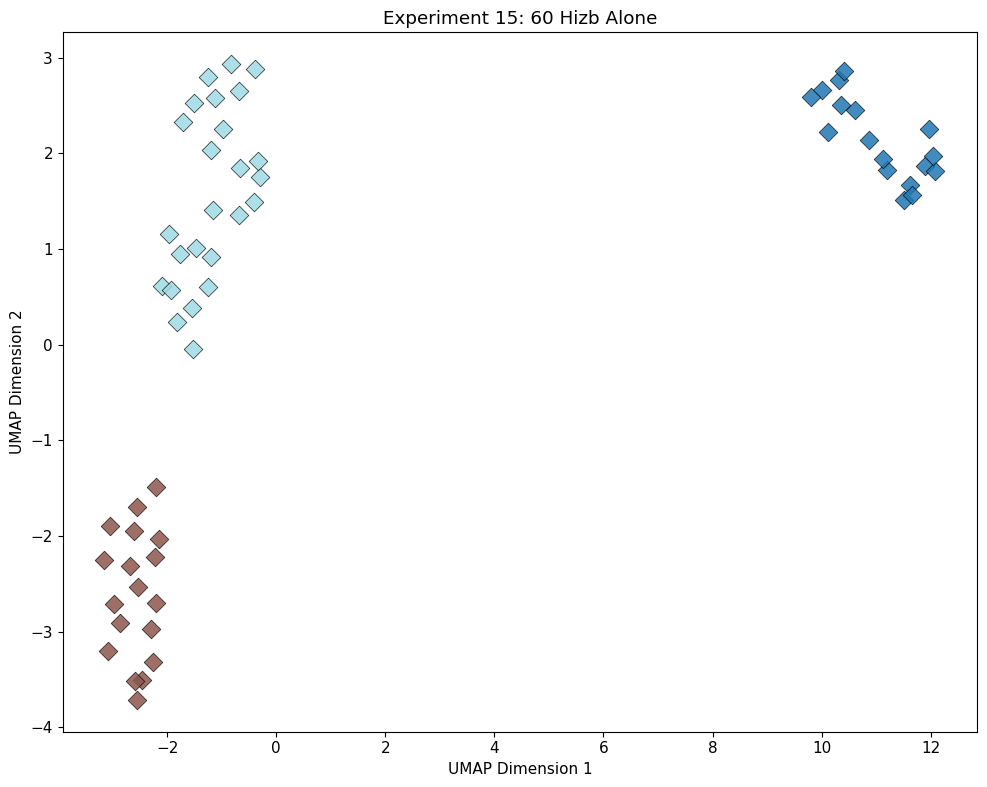

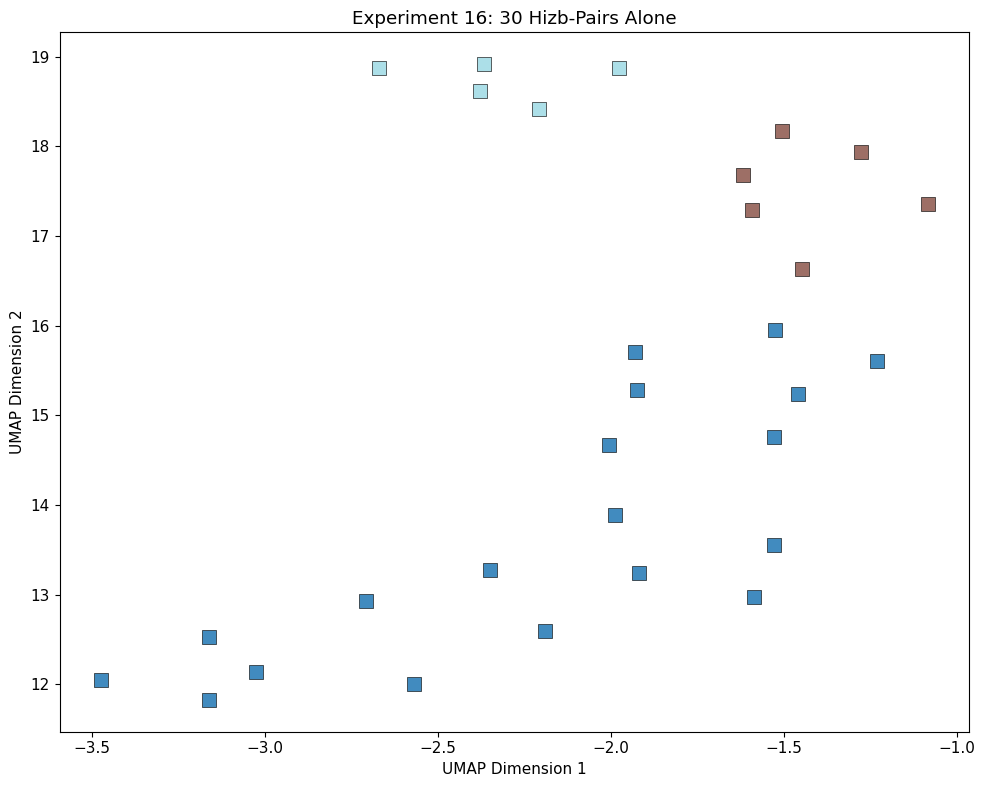

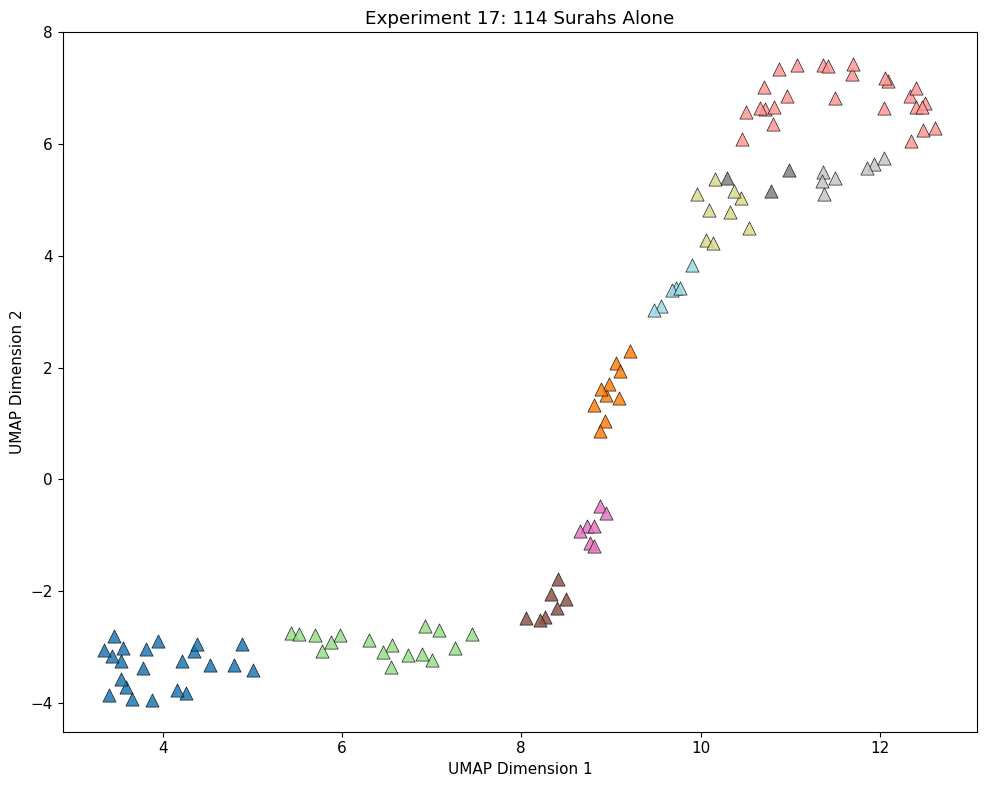

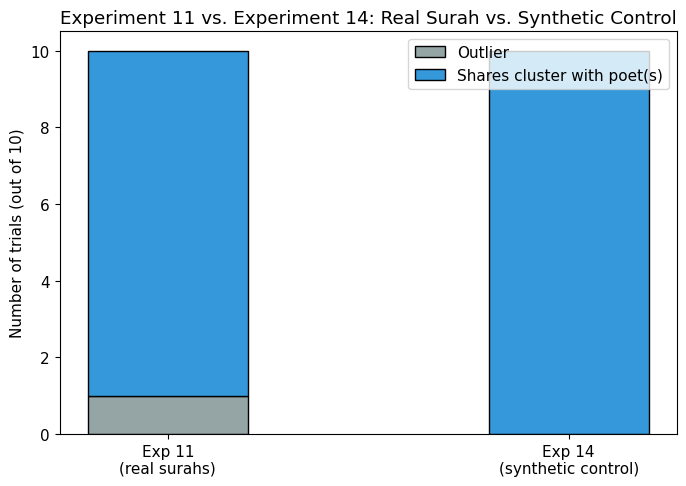

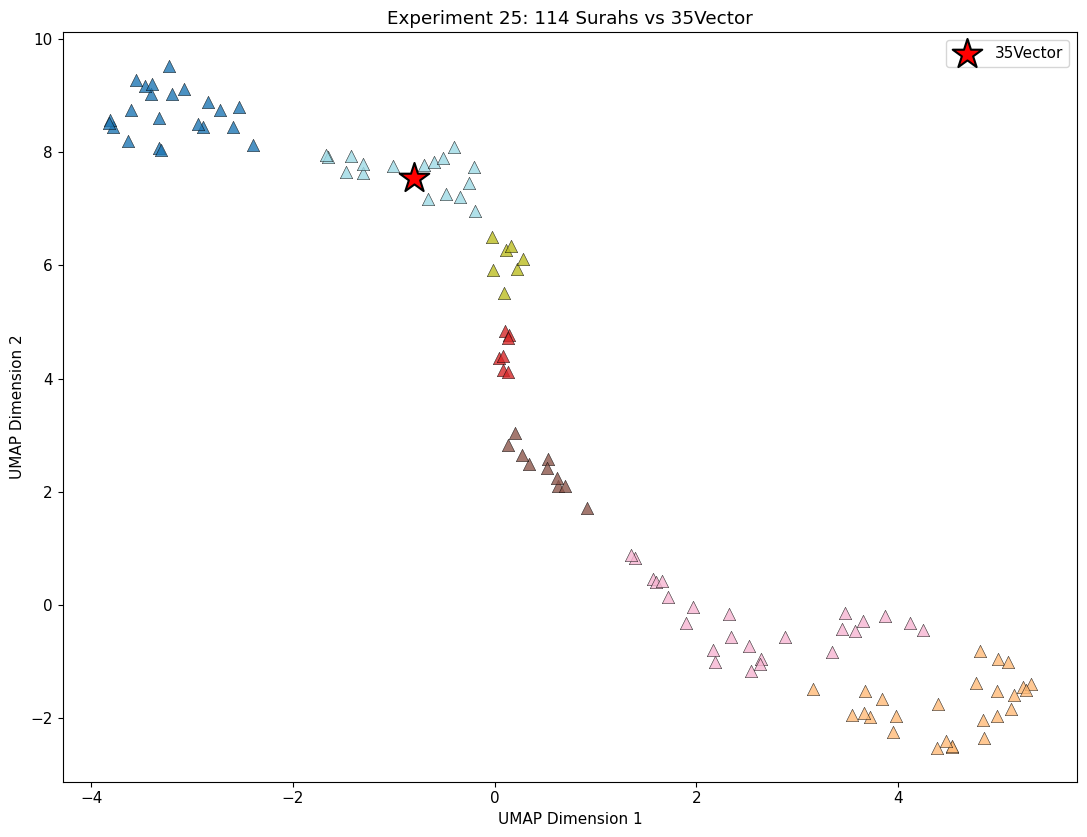

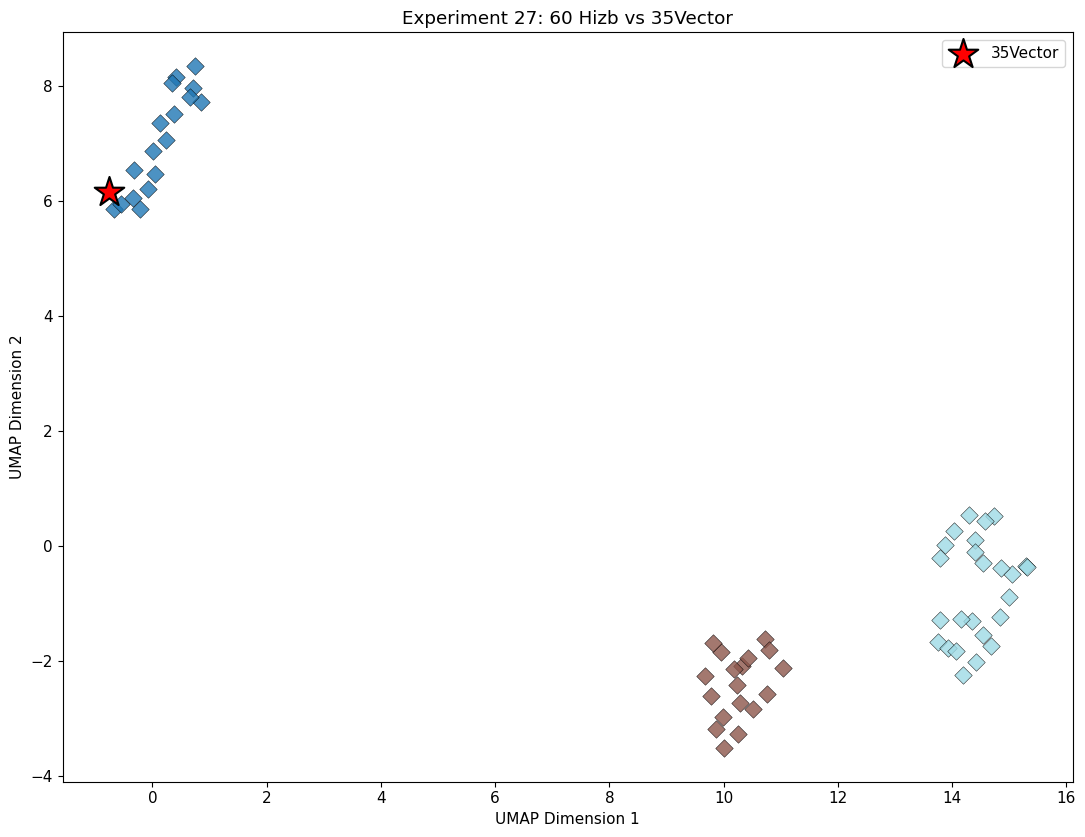

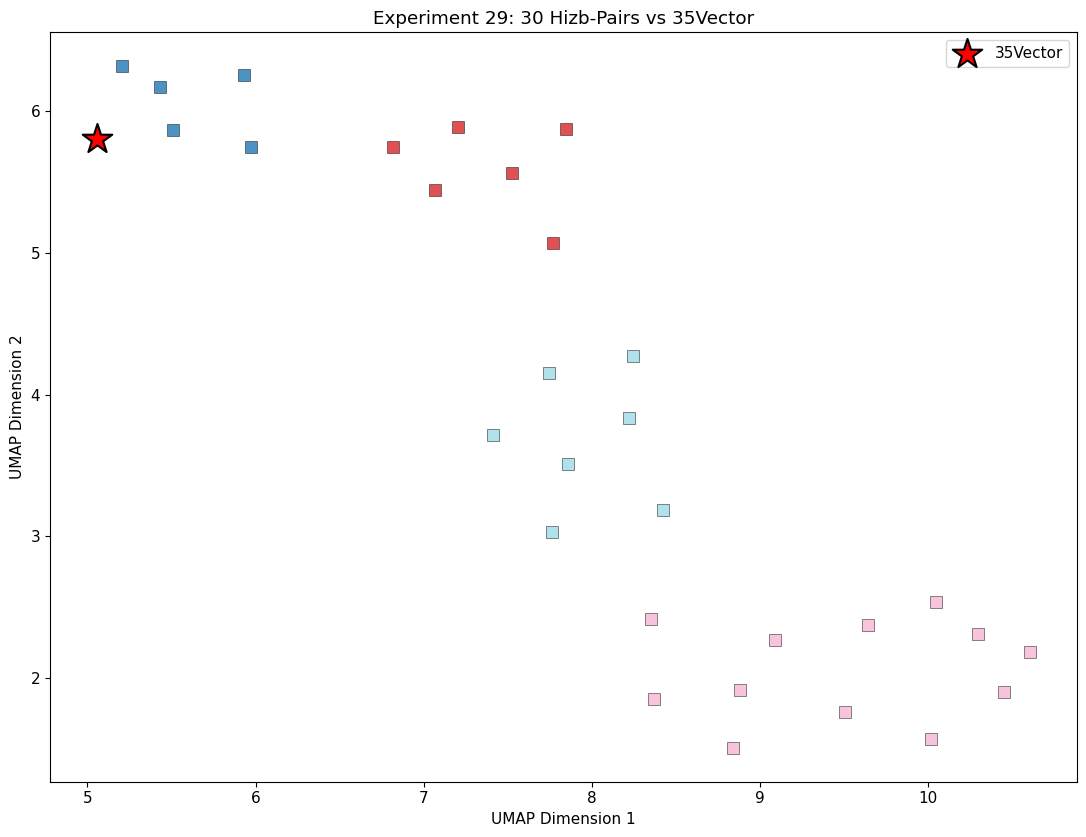

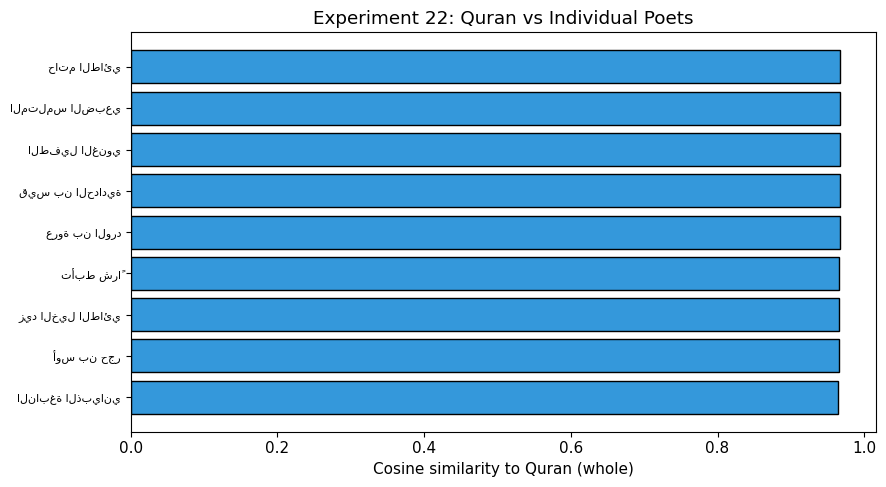

All figures saved.


In [17]:
# CELL 16 -- Figures (merged from both experiment batches)
def plot_single_type(df, title, save_name, marker="o"):
    fig, ax = plt.subplots(figsize=(10, 8))
    unique_clusters = sorted(df["cluster"].unique())
    n_clust_plot = len([c for c in unique_clusters if c >= 0])
    colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))
    for cl in unique_clusters:
        sub = df[df["cluster"] == cl]
        color = "gray" if cl == -1 else colors[cl % len(colors)]
        ax.scatter(sub["umap_x"], sub["umap_y"], c=[color], marker=marker, s=90,
                  alpha=0.85, edgecolors="black", linewidth=0.5)
    ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_vs_vector(df, title, save_name, vector_label, unit_marker):
    fig, ax = plt.subplots(figsize=(11, 8.5))
    unique_clusters = sorted(df["cluster"].unique())
    n_clust_plot = len([c for c in unique_clusters if c >= 0])
    colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))
    for cl in unique_clusters:
        sub = df[df["cluster"] == cl]
        color = "gray" if cl == -1 else colors[cl % len(colors)]
        units = sub[sub["type"] != vector_label]
        vec = sub[sub["type"] == vector_label]
        if len(units) > 0:
            ax.scatter(units["umap_x"], units["umap_y"], c=[color], marker=unit_marker, s=80,
                      alpha=0.8, edgecolors="black", linewidth=0.4)
        if len(vec) > 0:
            ax.scatter(vec["umap_x"], vec["umap_y"], c="red", marker="*", s=500,
                      edgecolors="black", linewidth=1.5, zorder=10, label=vector_label)
    ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
    ax.set_title(title)
    if ax.get_legend_handles_labels()[0]:
        ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

# Experiments 15-17: Quranic units alone
plot_single_type(exp15_df, "Experiment 15: 60 Hizb Alone", "experiment15_umap.png", "D")
plot_single_type(exp16_df, "Experiment 16: 30 Hizb-Pairs Alone", "experiment16_umap.png", "s")
plot_single_type(exp17_df, "Experiment 17: 114 Surahs Alone", "experiment17_umap.png", "^")

# Experiment 14 vs Experiment 11 comparison
fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Exp 11\n(real surahs)", "Exp 14\n(synthetic control)"]
outlier_counts = [1, n_outlier_14]
shared_counts = [9, 10 - n_outlier_14]
x = np.arange(2)
ax.bar(x, outlier_counts, width=0.4, label="Outlier", color="#95a5a6", edgecolor="black")
ax.bar(x, shared_counts, width=0.4, bottom=outlier_counts, label="Shares cluster with poet(s)",
      color="#3498db", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel("Number of trials (out of 10)")
ax.set_title("Experiment 11 vs. Experiment 14: Real Surah vs. Synthetic Control")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "experiment14_vs_11.png", dpi=300, bbox_inches="tight")
plt.show()

# Experiments 25/27/29: units vs 35Vector
plot_vs_vector(exp25_df, "Experiment 25: 114 Surahs vs 35Vector", "experiment25_umap.png", "35Vector", "^")
plot_vs_vector(exp27_df, "Experiment 27: 60 Hizb vs 35Vector", "experiment27_umap.png", "35Vector", "D")
plot_vs_vector(exp29_df, "Experiment 29: 30 Hizb-Pairs vs 35Vector", "experiment29_umap.png", "35Vector", "s")

# Experiment 22: similarity to each individual poet
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(exp22_df)), exp22_df["cosine_similarity"], color="#3498db", edgecolor="black")
ax.set_yticks(range(len(exp22_df)))
ax.set_yticklabels(exp22_df["poet"], fontsize=8)
ax.set_xlabel("Cosine similarity to Quran (whole)")
ax.set_title("Experiment 22: Quran vs Individual Poets")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "experiment22_bars.png", dpi=300, bbox_inches="tight")
plt.show()

print("All figures saved.")

In [18]:
# CELL 17 -- Final report covering all of Experiments 13-30
report_path = REPORTS_DIR / "experiments_13_30_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENTS 14-30: FULL REPORT\n")
    f.write("=" * 70 + "\n\n")

    f.write("EXPERIMENT 14: SYNTHETIC CONTROL TEST\n" + "-" * 40 + "\n")
    f.write(f"  Outliers: {n_outlier_14}/10 (Experiment 11 comparison: 1/10)\n")
    f.write(f"  Shared cluster with poets: {10-n_outlier_14}/10 (Experiment 11 comparison: 9/10)\n")

    f.write("\nEXPERIMENTS 15-17: QURANIC UNITS ALONE\n" + "-" * 40 + "\n")
    for name, metrics in [("Exp 15 (60 hizb)", exp15_metrics), ("Exp 16 (30 hizb-pairs)", exp16_metrics),
                          ("Exp 17 (114 surahs)", exp17_metrics)]:
        f.write(f"  {name}: {metrics}\n")

    f.write("\nEXPERIMENT 18: ALLPOETS VS QURAN (WHOLE) -- DIRECT SIMILARITY\n" + "-" * 40 + "\n")
    f.write(f"  Cosine similarity: {sim_18:.4f}\n")

    f.write("\nEXPERIMENTS 19-21: ALLPOETS + SURAHS / HIZB / HIZB-PAIRS\n" + "-" * 40 + "\n")
    f.write(f"  Exp 19 (+114 surahs): {exp19_metrics}, AllPoets cluster={allpoets_row_19['cluster']}\n")
    f.write(f"  Exp 20 (+60 hizb): {exp20_metrics}, AllPoets cluster={allpoets_row_20['cluster']}\n")
    f.write(f"  Exp 21 (+30 hizb-pairs): {exp21_metrics}, AllPoets cluster={allpoets_row_21['cluster']}\n")

    f.write("\nEXPERIMENT 22: QURAN VS INDIVIDUAL POETS (NOT AVERAGED)\n" + "-" * 40 + "\n")
    f.write(exp22_df.to_string(index=False) + "\n")
    f.write(f"  Mean: {exp22_df['cosine_similarity'].mean():.4f}\n")

    f.write("\nEXPERIMENTS 23-24: QURAN (WHOLE) VS 35VECTOR / 19VECTOR\n" + "-" * 40 + "\n")
    f.write(f"  Exp 23 (vs 35Vector): {sim_23:.4f}\n")
    f.write(f"  Exp 24 (vs 19Vector): {sim_24:.4f}\n" if sim_24 is not None else "  Exp 24: skipped\n")

    f.write("\nEXPERIMENTS 25-30: QURANIC UNITS VS 35VECTOR / 19VECTOR\n" + "-" * 40 + "\n")
    for exp_num, data in sorted(exp_results_25_30.items()):
        f.write(f"  Experiment {exp_num}: {data['metrics']}, vector status: {data['vector_status']}\n")

    f.write("\nHOW TO READ THIS\n" + "-" * 40 + "\n")
    f.write("  Exp 14 is the key methodological check on Exp 11: if synthetic\n")
    f.write("  nonsense text gets absorbed into poet clusters at a similar rate\n")
    f.write("  to real surahs, that confirms the earlier finding was about\n")
    f.write("  clustering mechanics, not genuine stylistic overlap.\n")
    f.write("  Exp 18-30 apply the same 'lone point' reasoning to AllPoets,\n")
    f.write("  35Vector, and 19Vector -- each is a single aggregate point facing\n")
    f.write("  many Quranic units, so cluster membership alone should be read\n")
    f.write("  alongside the direct similarity numbers (Exp 18, 23, 24), not\n")
    f.write("  instead of them.\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\experiments_13_30_report.txt

EXPERIMENTS 14-30: FULL REPORT

EXPERIMENT 14: SYNTHETIC CONTROL TEST
----------------------------------------
  Outliers: 0/10 (Experiment 11 comparison: 1/10)
  Shared cluster with poets: 10/10 (Experiment 11 comparison: 9/10)

EXPERIMENTS 15-17: QURANIC UNITS ALONE
----------------------------------------
  Exp 15 (60 hizb): {'n_entities': 60, 'n_clusters': 3, 'n_outliers': 0, 'silhouette': 0.8822755813598633}
  Exp 16 (30 hizb-pairs): {'n_entities': 30, 'n_clusters': 3, 'n_outliers': 0, 'silhouette': 0.5434573888778687}
  Exp 17 (114 surahs): {'n_entities': 114, 'n_clusters': 9, 'n_outliers': 3, 'silhouette': 0.6625418663024902}

EXPERIMENT 18: ALLPOETS VS QURAN (WHOLE) -- DIRECT SIMILARITY
----------------------------------------
  Cosine similarity: 0.9538

EXPERIMENTS 19-21: ALLPOETS + SURAHS / HIZB / HIZB-PAIRS
----------------------------------------
  Exp 19 (+114 surahs): {'n_entities': 115, 'n_clusters': 4, 'n_o

## Done

Output in `output/`:
- All CSVs and figures from Experiments 13-30
- `output/reports/experiments_13_30_report.txt` — everything in one file

Send this back the same way as before and I'll build the report.